In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
code_root = project_root / "neuralbi_diff" / "gbi_diff"
code_root = project_root / "neuralbi_diff"
sys.path.extend([str(project_root), str(code_root)])
print(sys.path)

['/home/robin/miniconda3/envs/gbi/lib/python312.zip', '/home/robin/miniconda3/envs/gbi/lib/python3.12', '/home/robin/miniconda3/envs/gbi/lib/python3.12/lib-dynload', '', '/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages', '/home/robin/projects/lab_project/neuralgbi_diffusion', '/home/robin/projects/lab_project/neuralgbi_diffusion/neuralbi_diff']


In [3]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from sourcerer.simulators import TwoMoonsSimulator
from torch import Tensor
from tqdm import tqdm

from gbi_diff.model.lit_module import Guidance
from gbi_diff.sampling.diffusion import DiffusionSampler
from gbi_diff.sampling.utils import load_specified_data, load_misspecified_data
from gbi_diff.utils.configs.sampling_diffusion import Config
from gbi_diff.utils.criterion import SBICriterion
from gbi_diff.utils.metrics import compute_distances, mse_dist,mmd_dist
from gbi_diff.utils.plot import _pair_plot
import matplotlib as mpl
import seaborn as sns

colors_tab10 = mpl.colormaps["tab10"]
colors_tab20 = mpl.colormaps["tab20"]


# specify matplotlib rc file
plt.style.use(str(project_root / ".matplotlibrc"))

/home/robin/miniconda3/envs/gbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def plot_guidance_analytics_2d(
    samples: Tensor,
    gt_sample: Tensor,
    gt_distance: Tensor,
    pred_distance: Tensor,
    pred_grad: Tensor,
    title: str,
):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(
        ncols=2, nrows=2, sharex=True, sharey=True, figsize=(4, 4)
    )

    grad_norm = torch.linalg.norm(pred_grad, dim=-1)
    if len(pred_grad.shape) == 3:
        gt_sample = gt_sample.mean(0)
        samples = samples.mean(1)
        pred_grad = pred_grad.mean(1)
        grad_norm = grad_norm.mean(-1)

    ax1.scatter(*samples.T, c=gt_distance)
    ax1.scatter(*gt_sample, c="r")
    ax1.set_title("GT")

    ax2.scatter(*samples.T, c=pred_distance)
    ax2.quiver(*samples.T, *pred_grad.T)
    ax2.scatter(*gt_sample, c="r")
    ax2.set_title("Guidance")

    difference = pred_distance - gt_distance
    ax3.scatter(*samples.T, c=difference - difference.mean(), cmap="coolwarm")
    ax3.scatter(*gt_sample, c="k")
    ax3.set_title("Difference: Guidance - GT")

    ax4.scatter(*samples.T, c=grad_norm, cmap="inferno")
    ax4.scatter(*gt_sample, c="r")
    ax4.set_title("Gradient Magnitude")

    fig.suptitle(title)
    fig.tight_layout()


def get_guidance_analytics(theta: Tensor, x: Tensor, guidance: Guidance, t: int = 0):
    """_summary_

    Args:
        theta (Tensor): (batch_dim, theta_dim)
        x (Tensor): (n_target, x_dim)
        guidance (Guidance): guidance function
        t (int, optional): diffusion time in index space. Defaults to 0.
    """
    time_repr = guidance.get_diff_time_repr(np.ones(len(theta)) * t)
    theta = theta.detach()
    theta.requires_grad = True
    x = x.detach()
    x.requires_grad = True
    time_repr = time_repr.detach()
    time_repr.requires_grad = True
    pred_dist = guidance.forward(theta, x[None].repeat(len(theta), 1, 1, 1), time_repr)
    grad = torch.autograd.grad(outputs=pred_dist.sum(), inputs=(theta, x))
    theta = theta.detach()
    x = x.detach()
    pred_dist = pred_dist.detach()
    grad = [g.detach() for g in grad]

    return pred_dist, grad


def plot_corr(gt_distance, pred_dist, gradient=None):
    if gradient is not None:
        grad_norm = torch.linalg.norm(gradient, dim=-1)
        if len(grad_norm.shape) == 2:
            grad_norm = grad_norm.mean(-1)
        stack = torch.stack(
            [
                gt_distance,
                pred_dist.squeeze(),
                gt_distance - pred_dist.squeeze(),
                grad_norm,
            ]
        )
        labels = ["gt distance", "pred distance", "distance difference", "grad norm"]
    else:
        stack = torch.stack(
            [gt_distance, pred_dist.squeeze(), gt_distance - pred_dist.squeeze()]
        )
        labels = ["gt distance", "pred distance", "distance difference", "grad norm"]

    corr = torch.corrcoef(stack)
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        corr,
        vmax=1,
        vmin=-1,
        cmap="coolwarm",
        annot=True,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_aspect("equal")

In [5]:
res_net_guidance_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_guidance/gaussian_mixture/2025-04-03-09-30-35/lightning_logs/version_0/epoch=99-step=4000.ckpt"
guidance = Guidance.load_from_checkpoint(res_net_guidance_ckpt)

Compute mmd_dist distances: 100%|██████████| 1000/1000 [00:00<00:00, 1199.62sample/s]


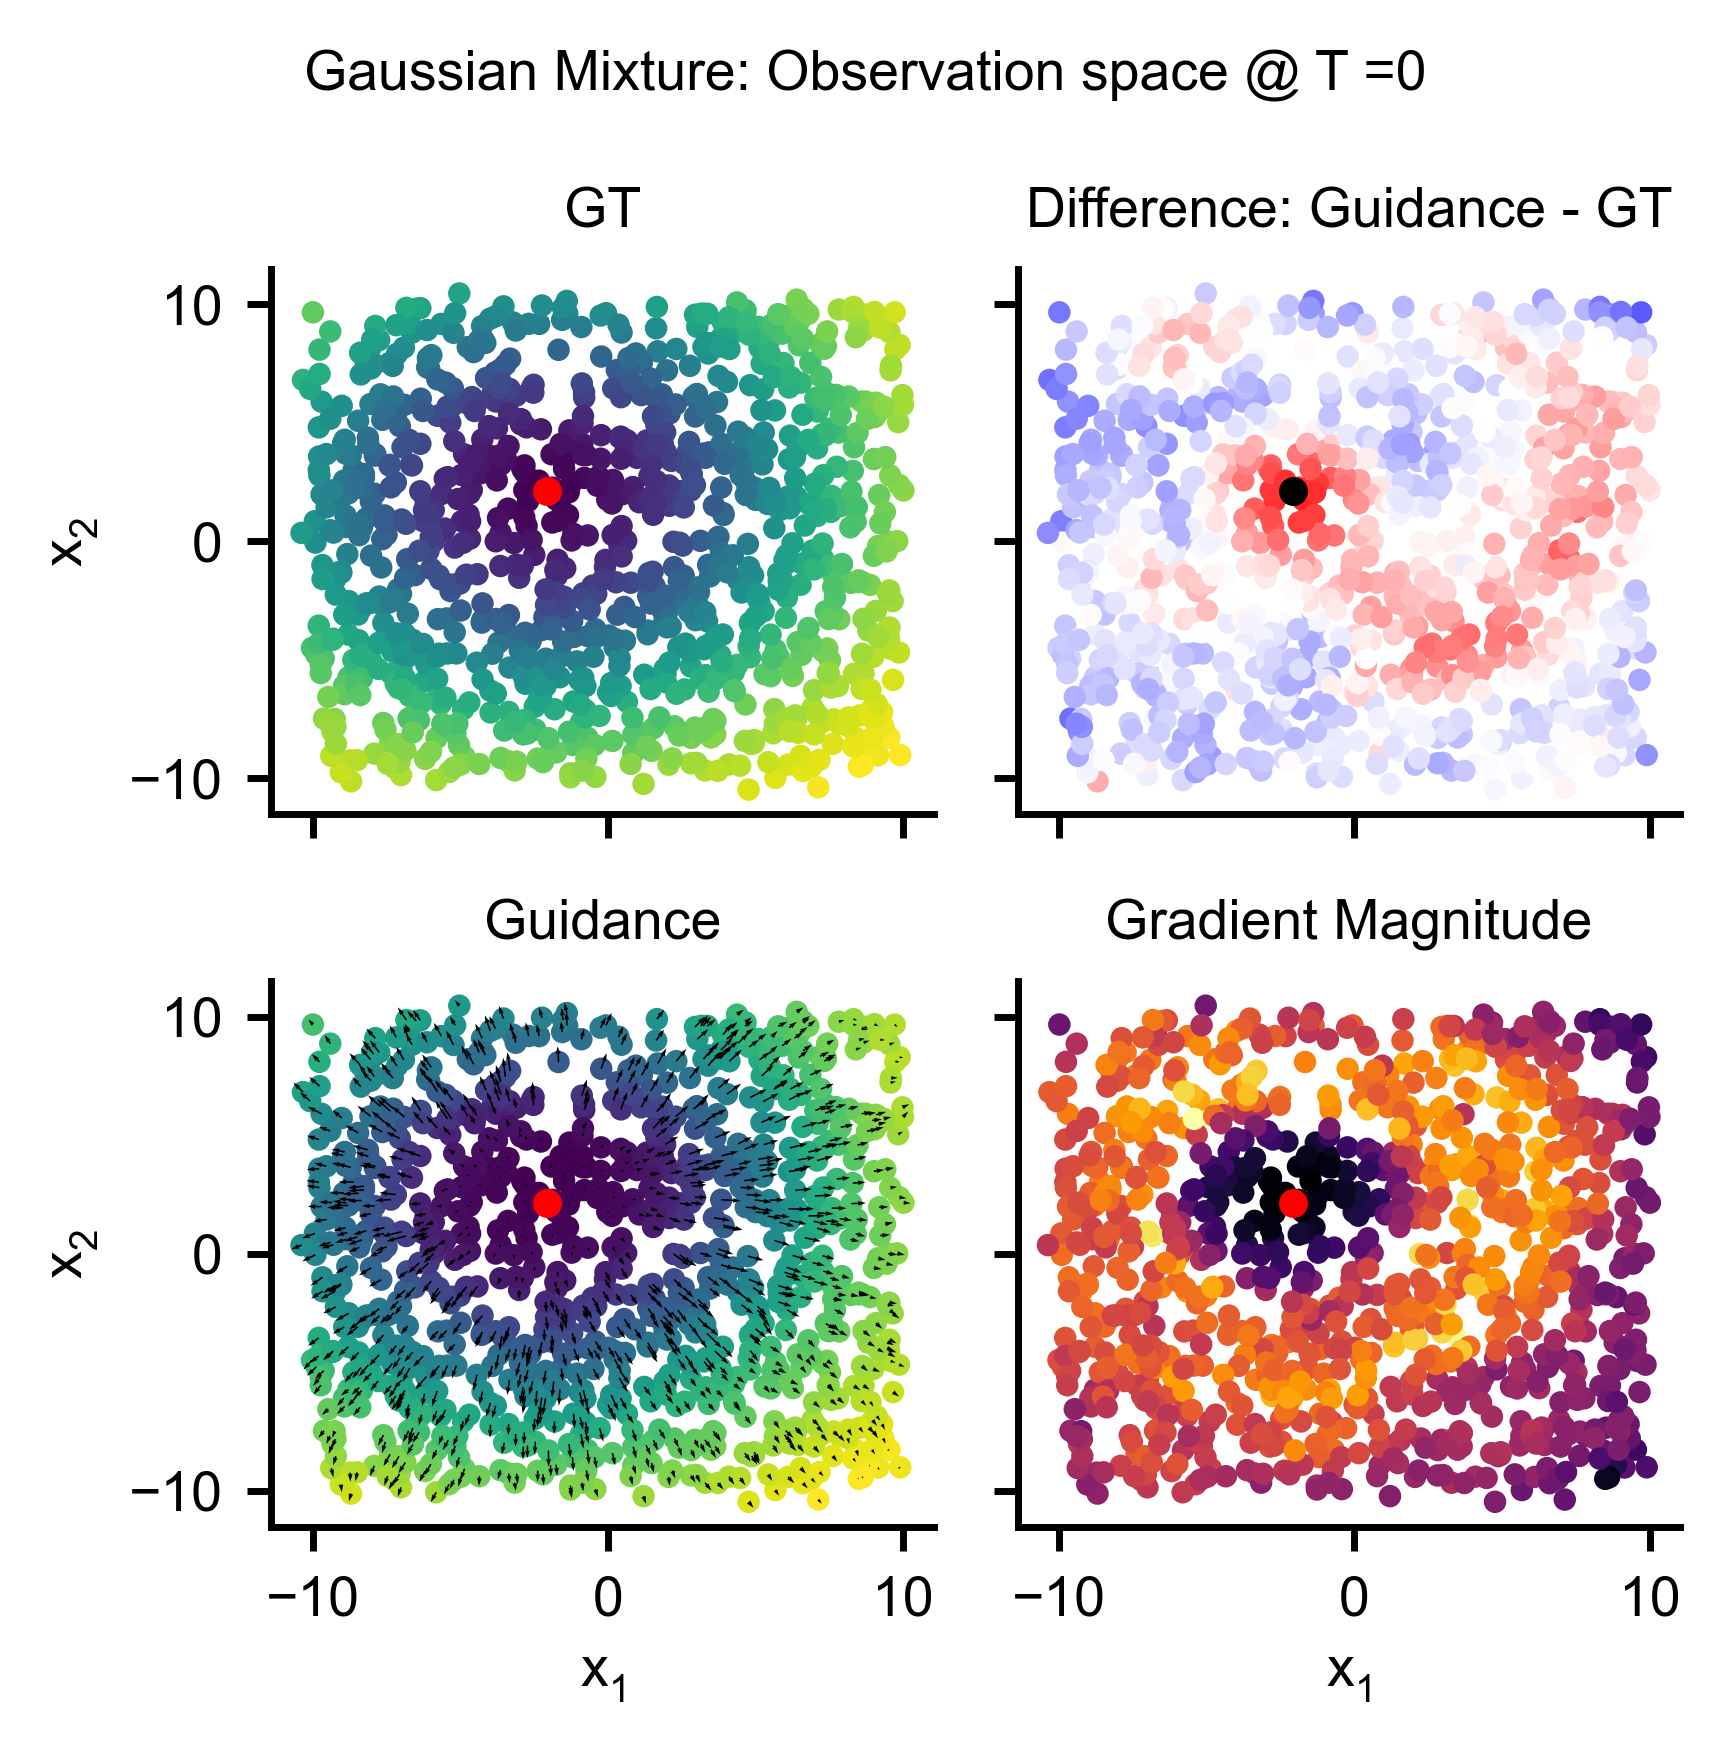

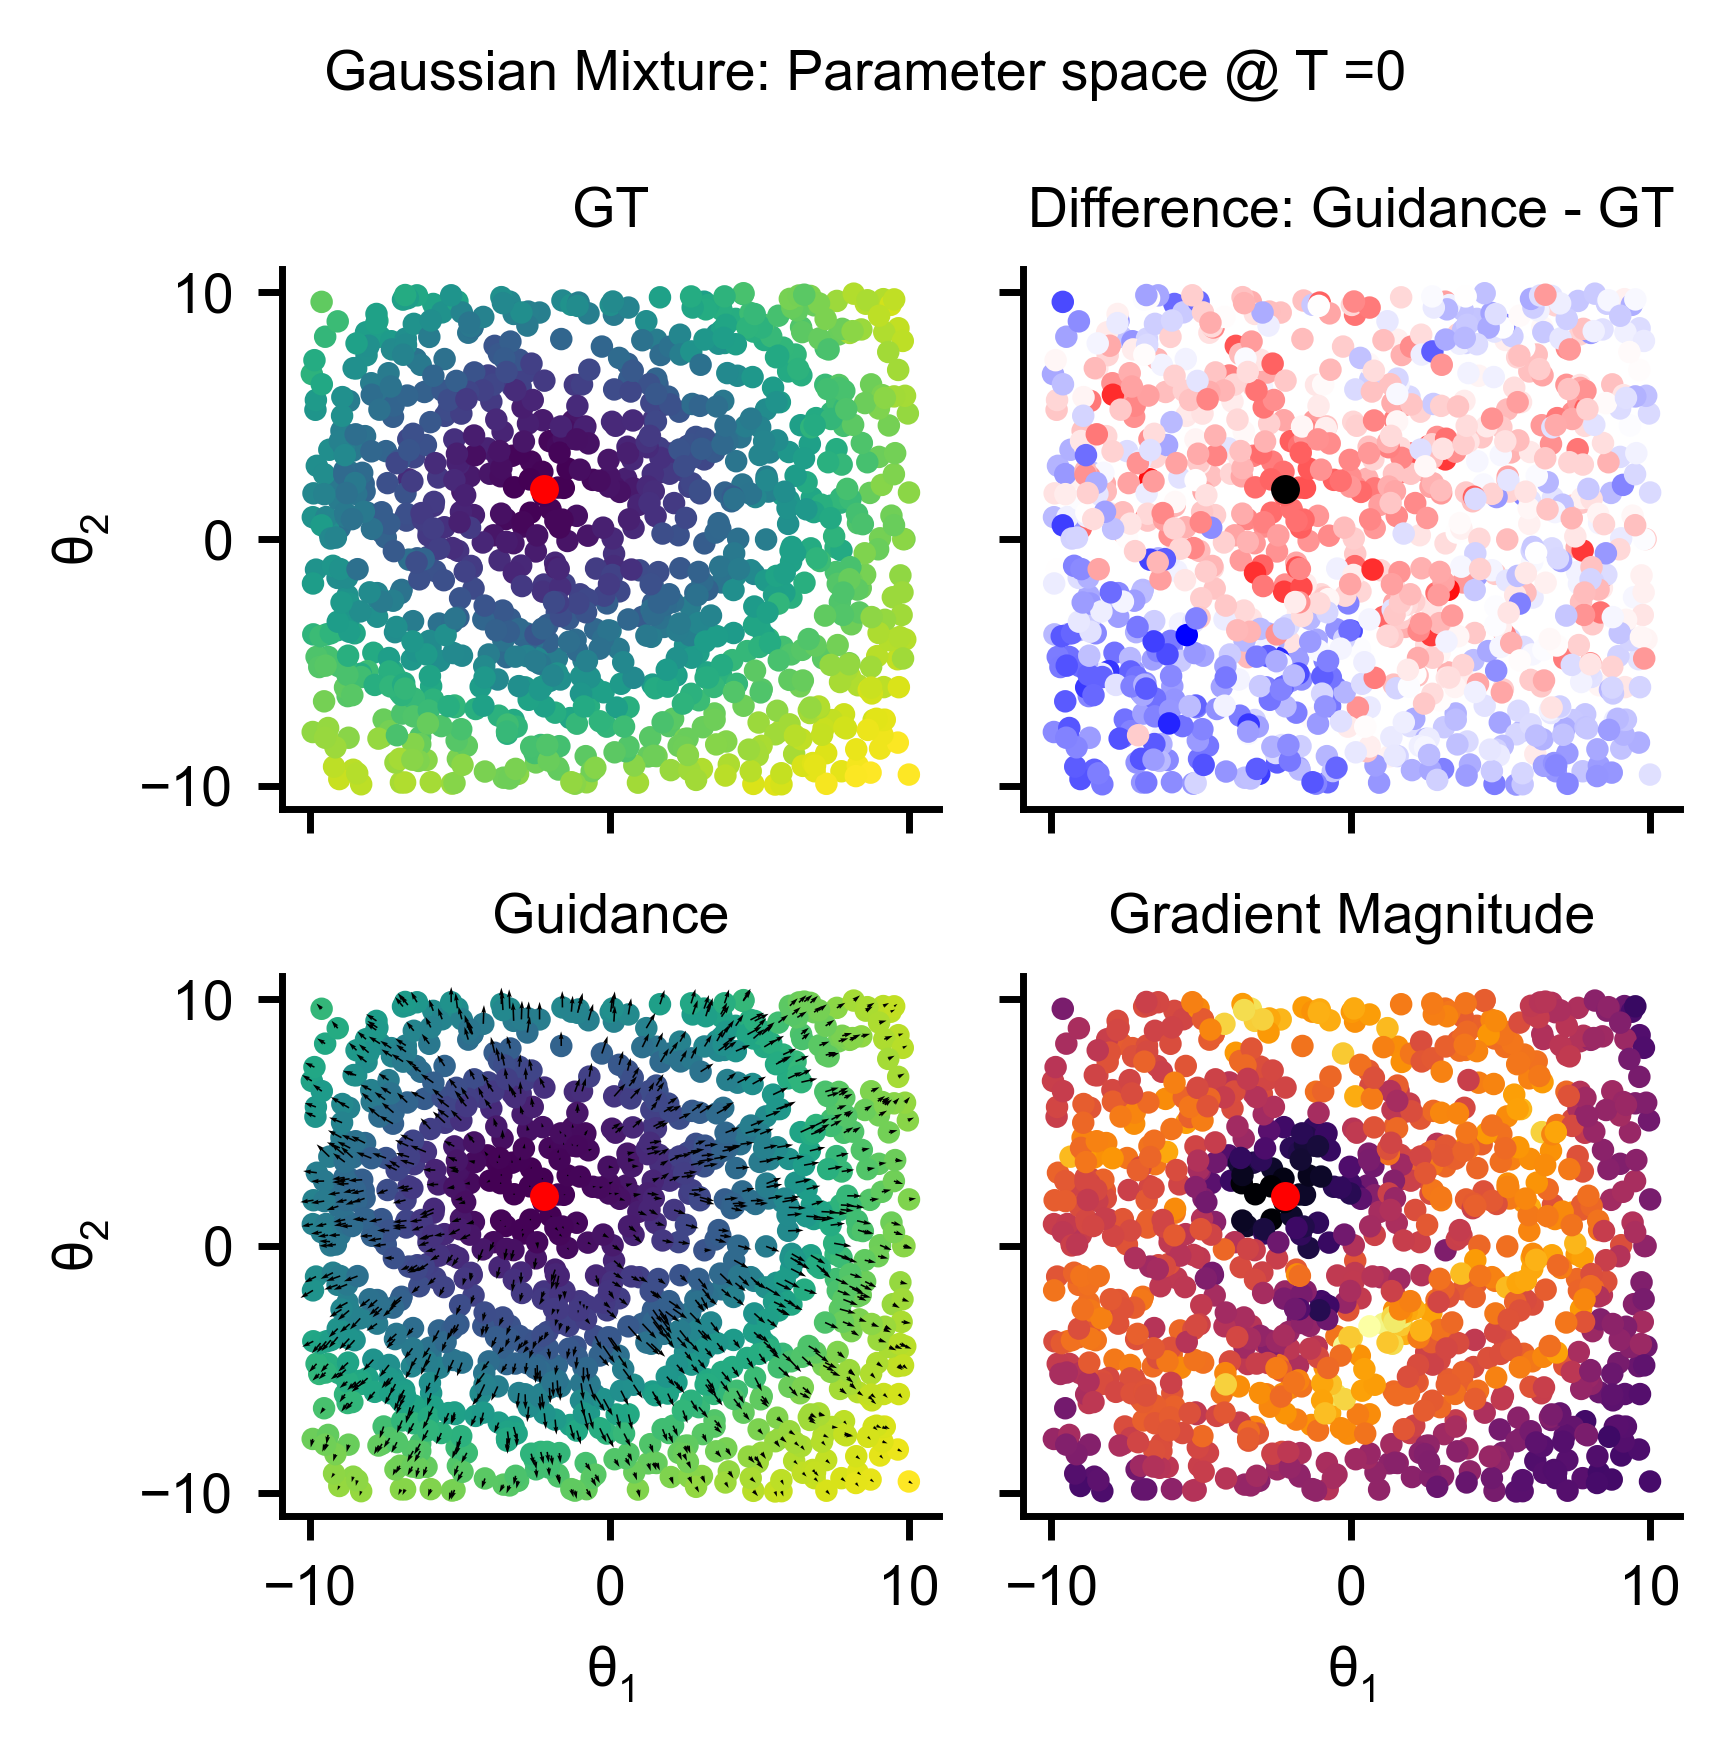

In [8]:
from notebooks.plot_utils import plot_guidance_analytics_2D, get_guidance_analytics


x, theta = load_specified_data("../data/gaussian_mixture_1000.pt")
dist_matrix = compute_distances(mmd_dist, x, x)

idx = 2
T = 0

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta[[idx]], x, guidance, T)
fig, axs = plot_guidance_analytics_2D(
    x,
    x[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    x_grad,
    title=f"Gaussian Mixture: Observation space @ {T =}",
)
axs[0, 0].set_ylabel(r"$x_2$")
axs[1, 0].set_ylabel(r"$x_2$")
axs[1, 0].set_xlabel(r"$x_1$")
axs[1, 1].set_xlabel(r"$x_1$")
fig.tight_layout()
fig.savefig("figures/guidance_eval_gaussian_mixture_obs_space.pdf")
# plot_corr(dist_matrix[idx], pred_dist, x_grad)

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta, x[[idx]], guidance, T)
fig, axs = plot_guidance_analytics_2D(
    theta,
    theta[idx],
    dist_matrix[idx],
    pred_dist.squeeze(),
    theta_grad,
    title=f"Gaussian Mixture: Parameter space @ {T =}",
)
axs[0, 0].set_ylabel(r"$\theta_2$")
axs[1, 0].set_ylabel(r"$\theta_2$")
axs[1, 0].set_xlabel(r"$\theta_1$")
axs[1, 1].set_xlabel(r"$\theta_1$")
fig.tight_layout()
fig.savefig("figures/guidance_eval_gaussian_mixture_param_space.pdf")
# plot_corr(dist_matrix[idx], pred_dist, theta_grad)

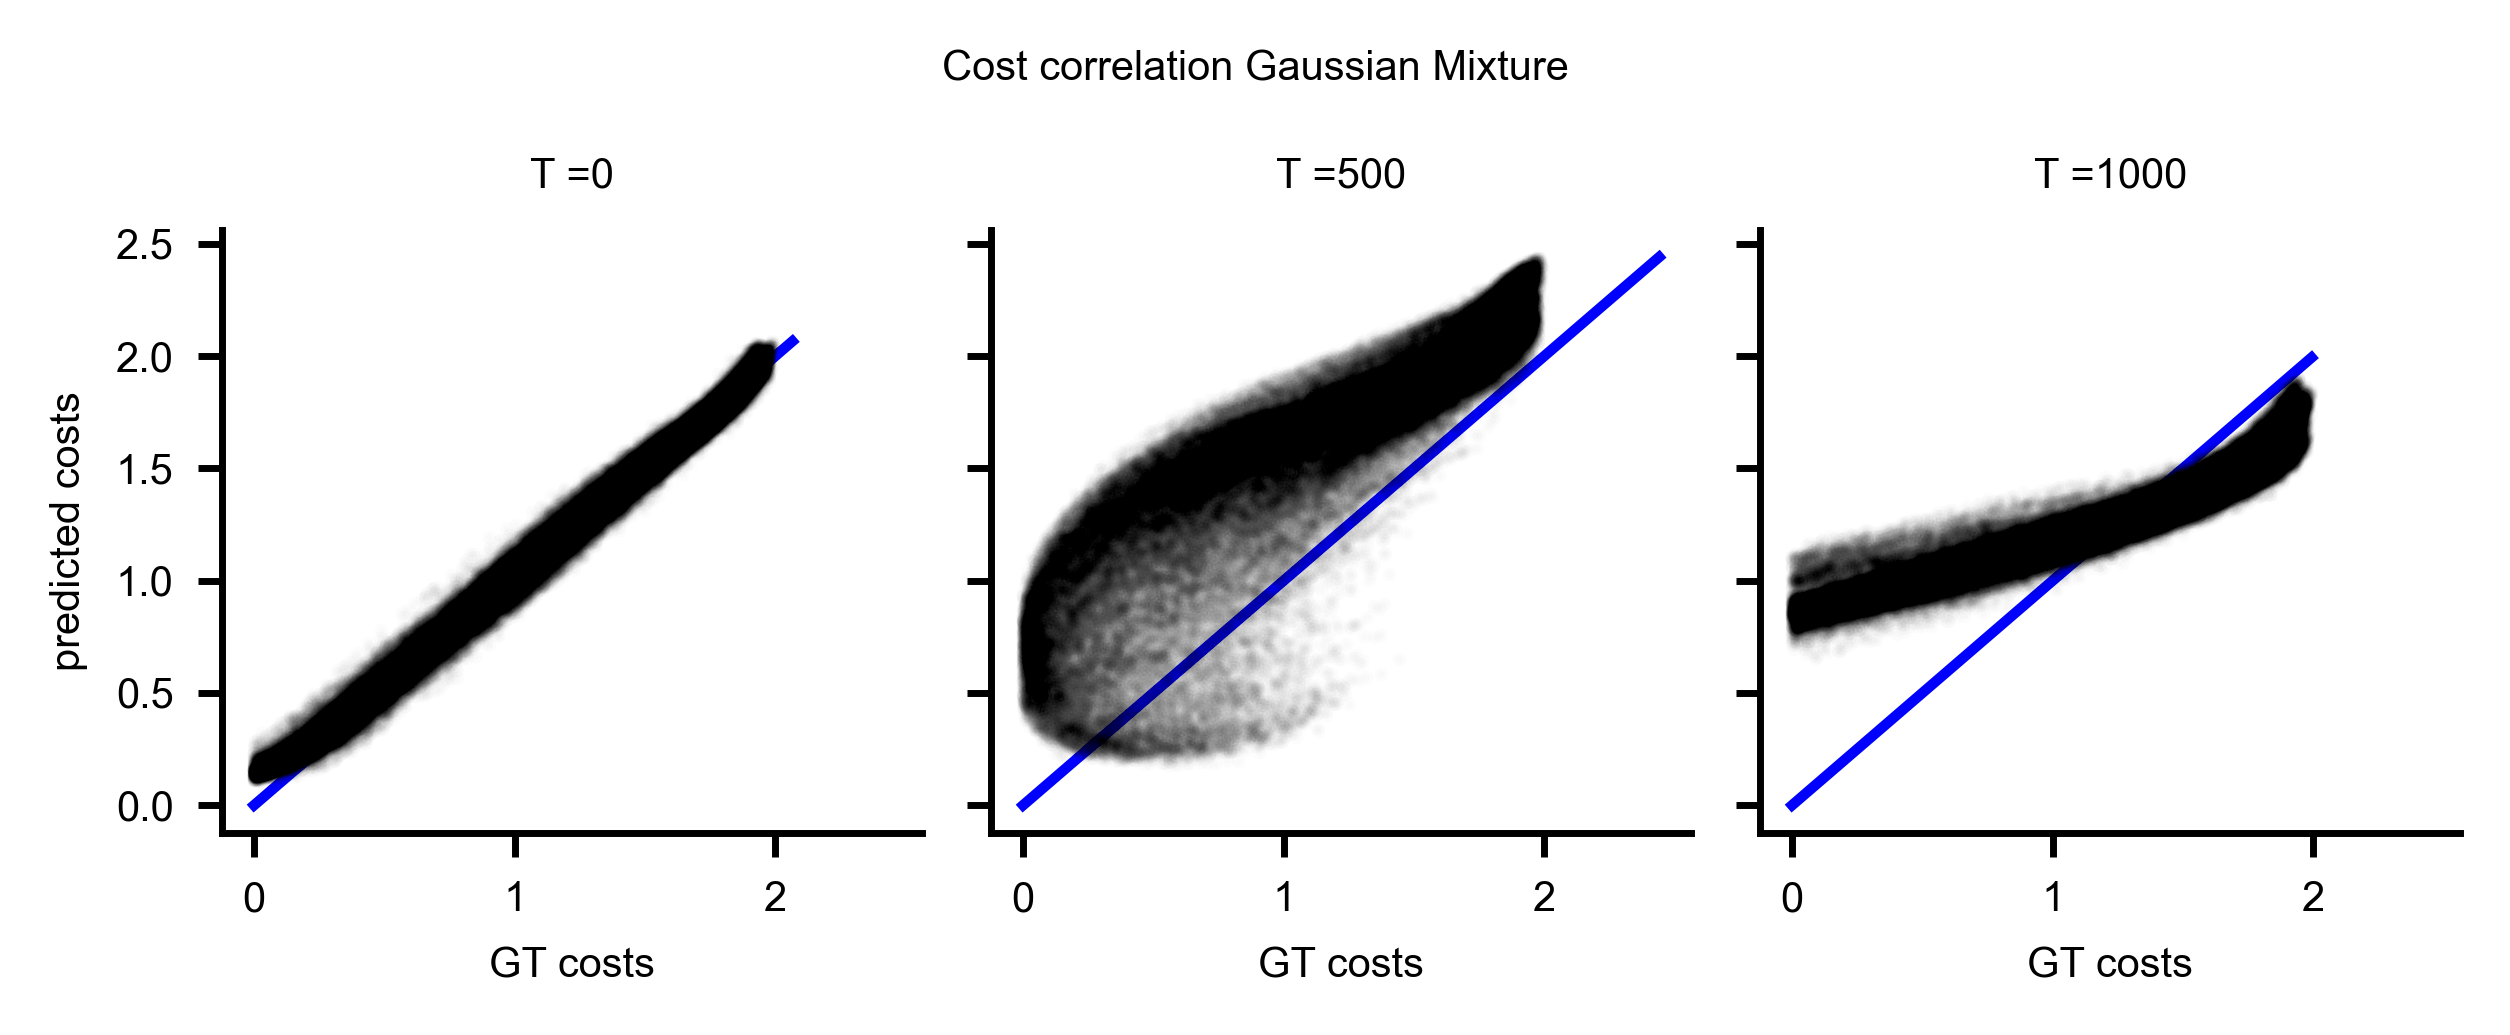

In [7]:
indices = np.arange(100)
fig, axs = plt.subplots(ncols=3, figsize=(5, 2), sharex=True, sharey=True)


for T, ax in zip([0, 500, 1000], (axs)):
    with torch.no_grad():
        time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * T)
        pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1, 1), time_repr)

    outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
    ax.plot([0, outer], [0, outer], color="blue", zorder=-1)
    ax.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
    ax.set_title(f"{T =}")
    ax.set_xlabel("GT costs")

axs[0].set_ylabel("predicted costs")
fig.suptitle("Cost correlation Gaussian Mixture")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_gaussian_mixture.png")

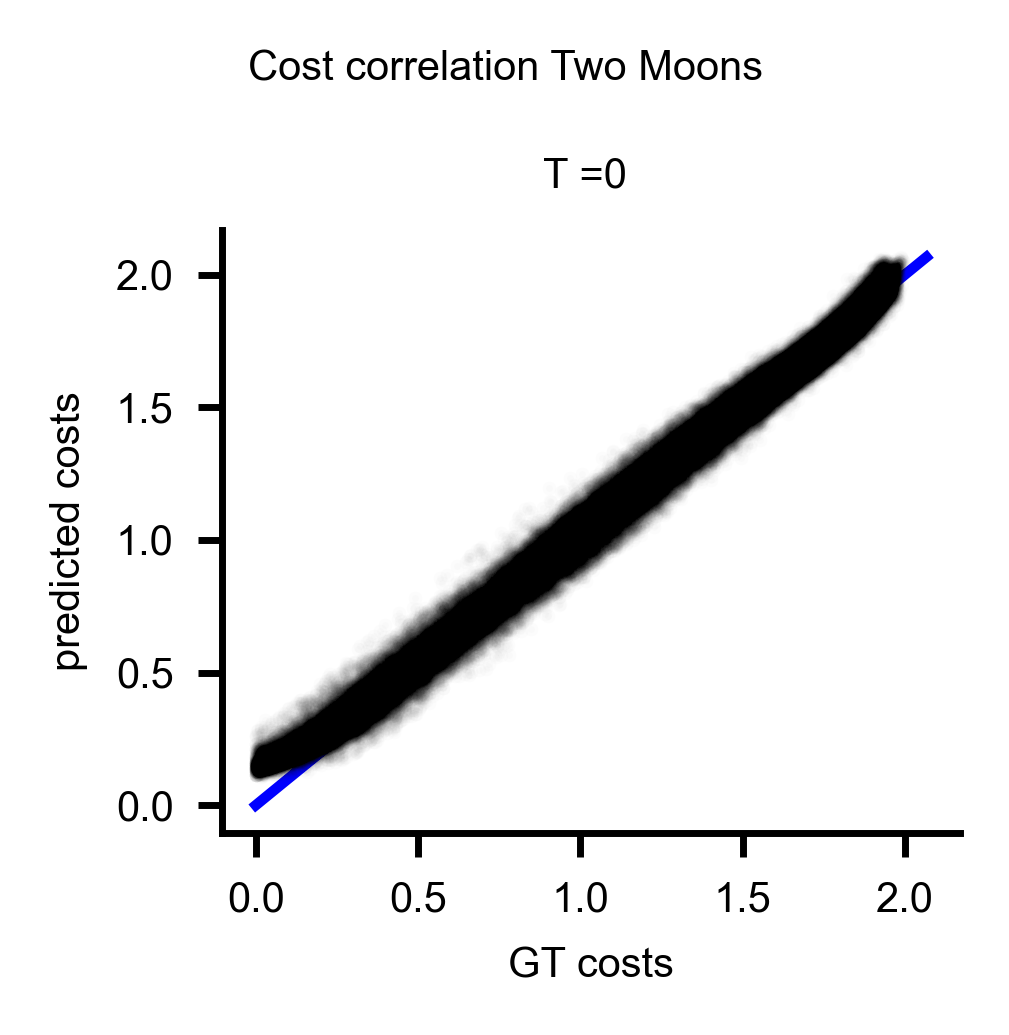

In [9]:
indices = np.arange(100)
fig, ax = plt.subplots(figsize=(2, 2), sharex=True, sharey=True)


with torch.no_grad():
    time_repr = guidance.get_diff_time_repr(np.ones(len(indices)) * 0)
    pred_dist = guidance.forward(theta[[indices]], x[None].repeat(len(indices), 1, 1, 1), time_repr)

outer = torch.maximum(dist_matrix[indices].max(), pred_dist.max())
ax.plot([0, outer], [0, outer], color="blue", zorder=-1)
ax.scatter(dist_matrix[indices].flatten(), pred_dist[:, :, 0].flatten(), s=1, alpha=0.01)
ax.set_title("T =0 ")
ax.set_xlabel("GT costs")

ax.set_ylabel("predicted costs")
fig.suptitle("Cost correlation Two Moons")  
fig.tight_layout()
fig.savefig("figures/guidance_eval_cost_corr_gaussian_mixture_T_0.png")


In [7]:
diffusion_ckpt = "/home/robin/projects/lab_project/neuralgbi_diffusion/results/train_diffusion/gaussian_mixture/2025-03-28-17-28-15/lightning_logs/version_0/epoch=89-step=3600.ckpt"
config: Config = Config.from_file("../config/sampling_diffusion.yaml")
config.observed_data_file = "../data/observed_data/gaussian_mixture_10.pt"
sampler = DiffusionSampler(
    diffusion_ckpt, res_net_guidance_ckpt, config.observed_data_file, config.beta, False, extended_information=True
)

In [8]:
sampler.update_gamma(400)
samples = sampler.forward(1000).detach()

Sample in observed data: 100%|██████████| 10/10 [00:58<00:00,  5.83s/it]


Text(0.5, 0.98, 'Two Moons: Parameter Space')

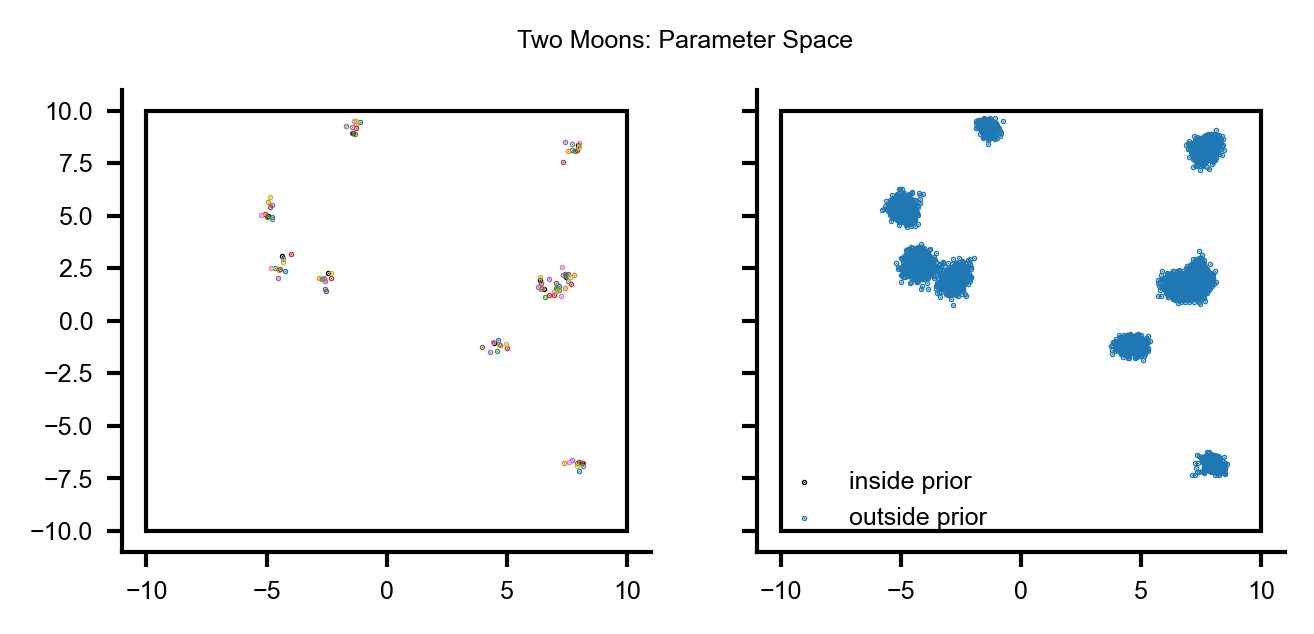

In [9]:
from typing import Tuple


def in_rectangle(samples: Tensor, corrds: Tensor, stretch: Tensor) -> Tensor:
    """_summary_

    Args:
        samples (Tensor): (n_samples, feature_dim)
        corrds (Tensor): minimum corner (feature_dim, )
        stretch (Tensor): maximum corner (feature_dim, )

    Returns:
        Tensor: binary mask (n_samples, )
    """
    assert (stretch >= 0).prod(), "all elements of stretch have to be greater equal 0"
    mask = (samples >= corrds) * (samples <= (corrds + stretch))
    mask = torch.prod(mask, dim=-1).bool()
    return mask


fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(5, 2))

rect = patches.Rectangle((-10, -10), 20, 20, linewidth=1, edgecolor='k', facecolor='none')
ax1.add_patch(rect)    
rect = patches.Rectangle((-10, -10), 20, 20, linewidth=1, edgecolor='k', facecolor='none')
ax2.add_patch(rect)    
for sample_idx in range(samples.shape[0]):
    ax1.scatter(*samples[:, sample_idx].T, s=.1)

mask = in_rectangle(samples, torch.tensor((-1.25, -1.25)), torch.tensor([2.5, 2.5]))
ax2.scatter(*samples[mask].T, s=0.1, label="inside prior")
ax2.scatter(*samples[~mask].T, s=0.1, label="outside prior")
ax2.legend()
fig.suptitle("Two Moons: Parameter Space")

/tmp/ipykernel_210226/1828716241.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])
/tmp/ipykernel_210226/1828716241.py:11: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  guidance_stats[mask].mean(dim=0) - guidance_stats[mask].std(dim=0),
/tmp/ipykernel_210226/1828716241.py:12: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  guidance_stats[mask].mean(dim=0) + guidance_stats[mask].std(dim=0),
/tmp/ipykernel_210226/1828716241.py:32: UserWarning: std(): degrees of freedom is <= 

torch.Size([10, 1001, 1000, 2])
torch.Size([10, 1000, 1000])
torch.Size([0, 1000])


/tmp/ipykernel_210226/1828716241.py:59: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  traj_dir_change[mask].mean(dim=0) - traj_dir_change[mask].std(dim=0),
/tmp/ipykernel_210226/1828716241.py:60: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1831.)
  traj_dir_change[mask].mean(dim=0) + traj_dir_change[mask].std(dim=0),


Text(0.5, 0, 'Diffusion Time')

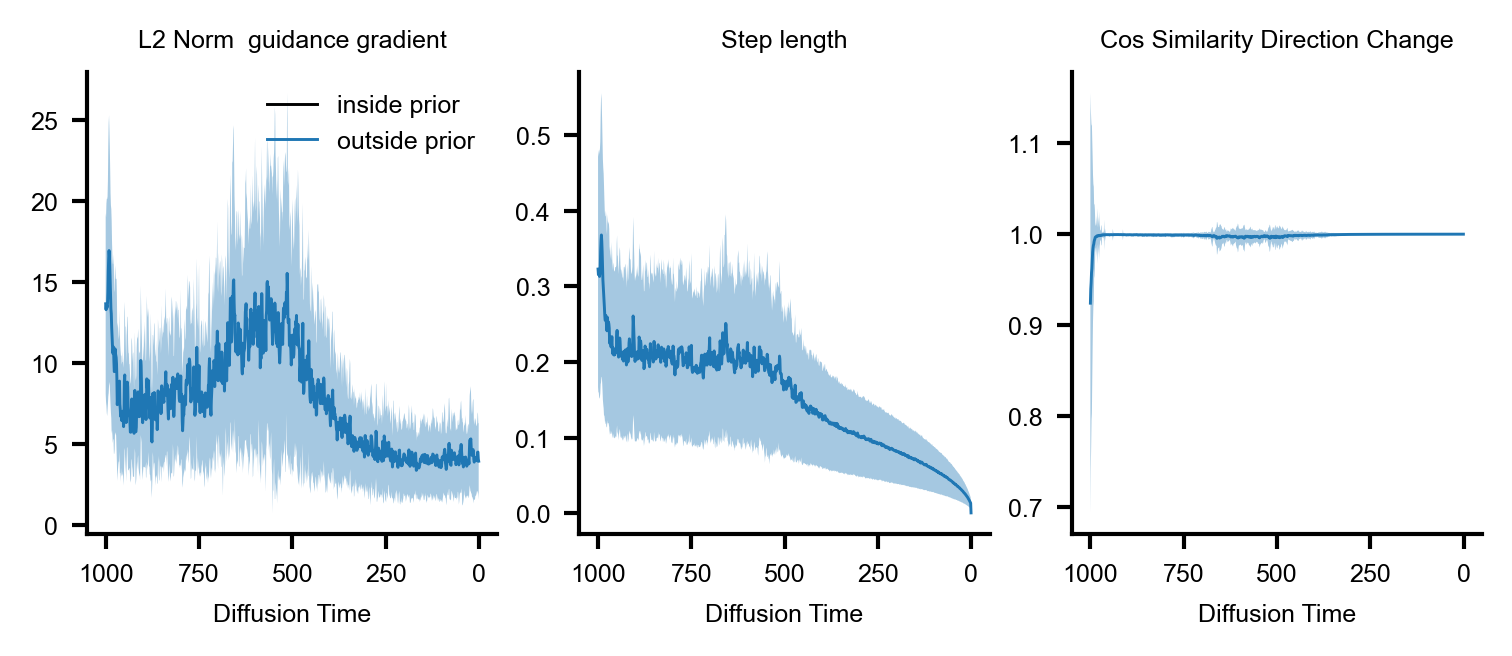

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, sharex=True, figsize=(6, 2))
ax1.set_xticklabels([None, *(np.linspace(0, 1, 5)[::-1] * 1000).astype(int)])
ax1.set_title("L2 Norm  guidance gradient")

guidance_grads = sampler._info["guidance_grad"]
guidance_stats = torch.linalg.norm(guidance_grads, dim=-1)
guidance_stats = guidance_stats.swapdims(1, 2)

ax1.fill_between(
    range(1000),
    guidance_stats[mask].mean(dim=0) - guidance_stats[mask].std(dim=0),
    guidance_stats[mask].mean(dim=0) + guidance_stats[mask].std(dim=0),
    alpha=0.2,
)
ax1.plot(guidance_stats[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax1.fill_between(
    range(1000),
    guidance_stats[~mask].mean(dim=0) - guidance_stats[~mask].std(dim=0),
    guidance_stats[~mask].mean(dim=0) + guidance_stats[~mask].std(dim=0),
    alpha=0.4,
)
ax1.plot(guidance_stats[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax1.set_xlabel("Diffusion Time")
ax1.legend()

trajectory = sampler._info["trajectory"]
step_length = torch.linalg.norm(torch.diff(trajectory, dim=1), dim=-1)
step_length = step_length.swapdims(1, 2)

ax2.fill_between(
    range(1000),
    step_length[mask].mean(dim=0) - step_length[mask].std(dim=0),
    step_length[mask].mean(dim=0) + step_length[mask].std(dim=0),
    alpha=0.2,
)
ax2.plot(step_length[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax2.fill_between(
    range(1000),
    step_length[~mask].mean(dim=0) - step_length[~mask].std(dim=0),
    step_length[~mask].mean(dim=0) + step_length[~mask].std(dim=0),
    alpha=0.4,
)
ax2.plot(step_length[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax2.set_xlabel("Diffusion Time")
ax2.set_title("Step length")

print(trajectory.shape)
traj_dir_change = (
    torch.sum(trajectory[:, :-1] * trajectory[:, 1:], dim=-1)
    / torch.linalg.norm(trajectory[:, :-1], dim=-1)
    / torch.linalg.norm(trajectory[:, 1:], dim=-1)
)
# traj_dir_change = torch.arccos(traj_dir_change)
print(traj_dir_change.shape)
traj_dir_change = traj_dir_change.swapdims(1, 2)
print(traj_dir_change[mask].shape)
ax3.fill_between(
    range(1000),
    traj_dir_change[mask].mean(dim=0) - traj_dir_change[mask].std(dim=0),
    traj_dir_change[mask].mean(dim=0) + traj_dir_change[mask].std(dim=0),
    alpha=0.2,
)
# ax3.plot(traj_dir_change[mask].T, linewidth=0.1, color="k")
# ax3.plot(traj_dir_change[~mask].T, linewidth=0.5, color=colors_tab10(0))
ax3.plot(traj_dir_change[mask].mean(dim=0), label="inside prior", linewidth=0.7)
ax3.fill_between(
    range(1000),
    traj_dir_change[~mask].mean(dim=0) - traj_dir_change[~mask].std(dim=0),
    traj_dir_change[~mask].mean(dim=0) + traj_dir_change[~mask].std(dim=0),
    alpha=0.4,
)
ax3.plot(traj_dir_change[~mask].mean(dim=0), label="outside prior", linewidth=0.7)
ax3.set_title("Cos Similarity Direction Change")
ax3.set_xlabel("Diffusion Time")


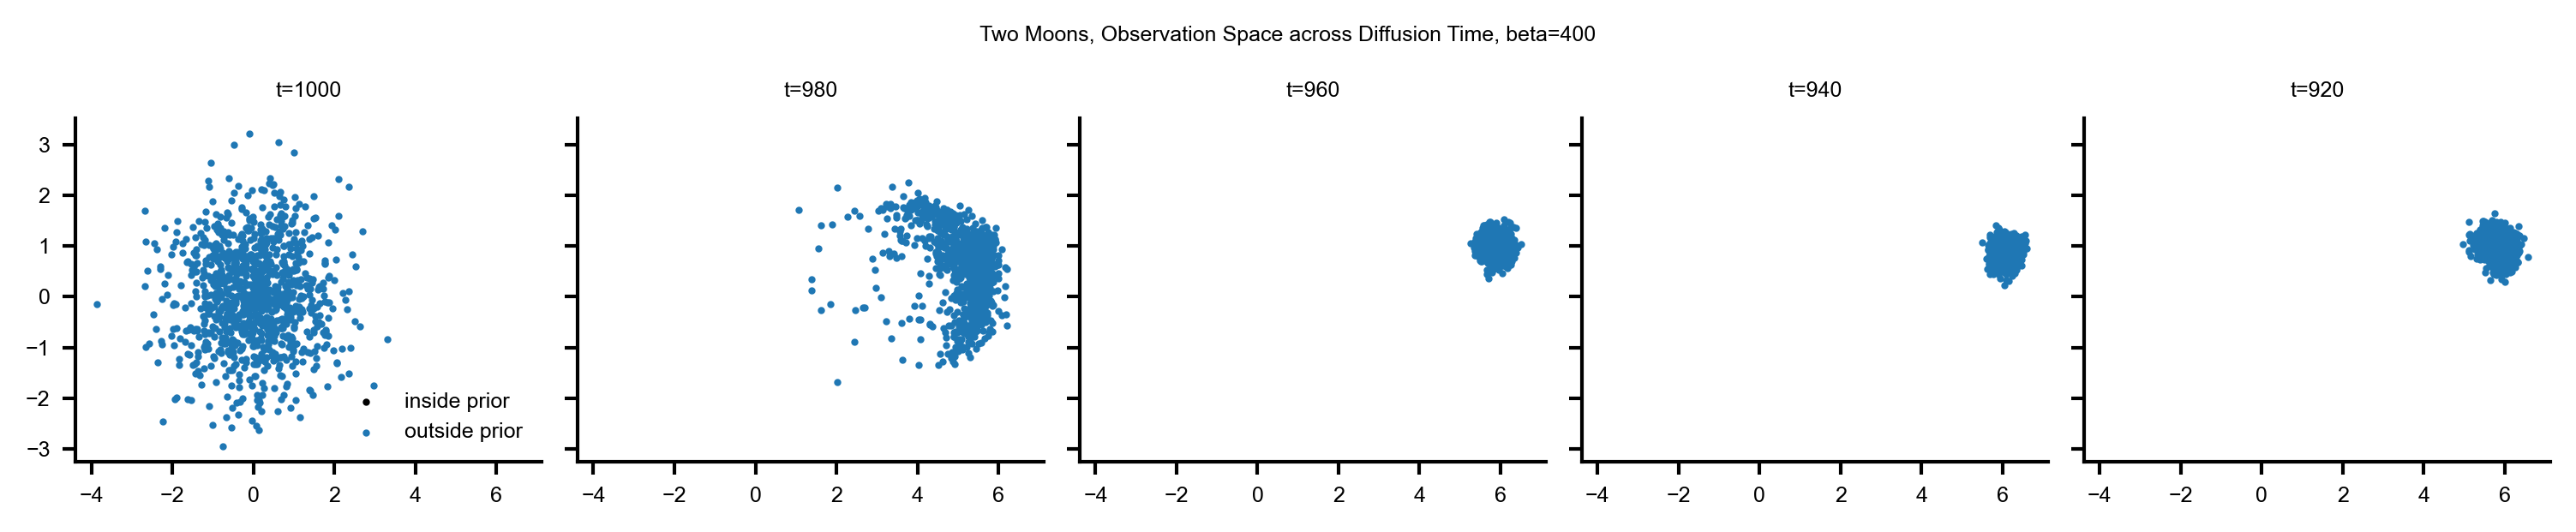

In [11]:
sample_idx = 8
times = [0, 20, 40, 60, 80]
fig, axs = plt.subplots(ncols=len(times), sharex=True, sharey=True, figsize=(10, 2))
for idx, t in enumerate(times):
    axs[idx].scatter(*trajectory[sample_idx,t, mask[sample_idx]].T, s=1, label="inside prior")
    axs[idx].scatter(*trajectory[sample_idx,t, ~mask[sample_idx]].T, s=1, label="outside prior")
    axs[idx].set_title(f"t={1000 - t}")
axs[0].legend()
fig.suptitle("Two Moons, Observation Space across Diffusion Time, beta=400")
fig.tight_layout()


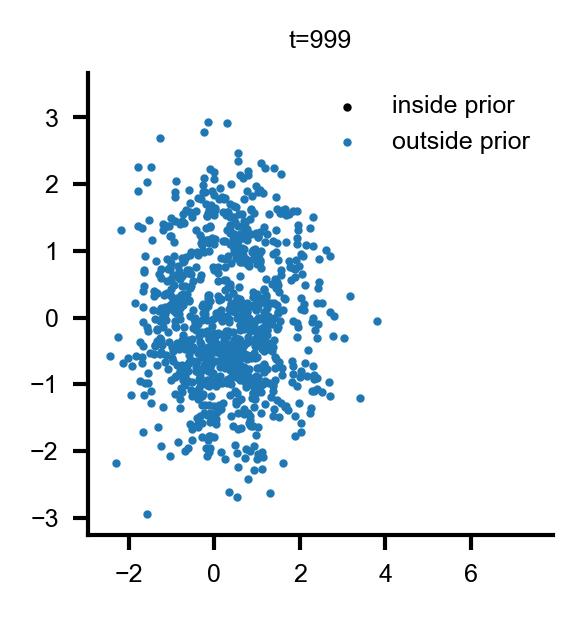

In [50]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(2, 2))
title = ax.set_title(f"t={1000}")
inside_scat = ax.scatter(
    *trajectory[sample_idx, 0, mask[sample_idx]].T, s=1, label="inside prior"
)
outside_scat = ax.scatter(
    *trajectory[sample_idx, 0, ~mask[sample_idx]].T, s=1, label="outside prior"
)

x_lim = (trajectory[sample_idx, ..., 0].min(), trajectory[sample_idx, ..., 0].max())
y_lim = (trajectory[sample_idx, ..., 1].min(), trajectory[sample_idx, ..., 1].max())
ax_x_lim = ax.set_xlim(x_lim)
ax_y_lim = ax.set_ylim(y_lim)
ax.legend()

def animate(t,):
    title.set_text(f"t={1000 - t}")
    inside_scat.set_offsets(trajectory[sample_idx, t, mask[sample_idx]])
    outside_scat.set_offsets(trajectory[sample_idx, t, ~mask[sample_idx]])
    return inside_scat, outside_scat


ani = FuncAnimation(fig, animate, repeat=True, frames=range(1, 1001) , interval=50)
writer = PillowWriter(fps=15, metadata=dict(artist="Me"), bitrate=1800)
ani.save("gaussian_mixture_scatter.gif", writer=writer)

Compute mmd_dist distances: 100%|██████████| 1000/1000 [00:00<00:00, 1266.12sample/s]


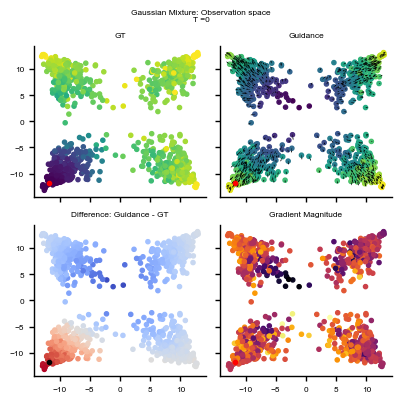

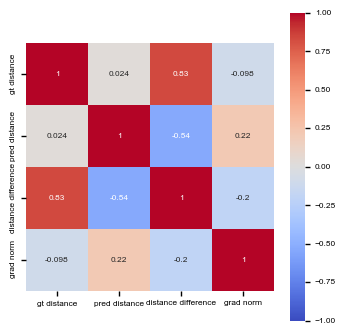

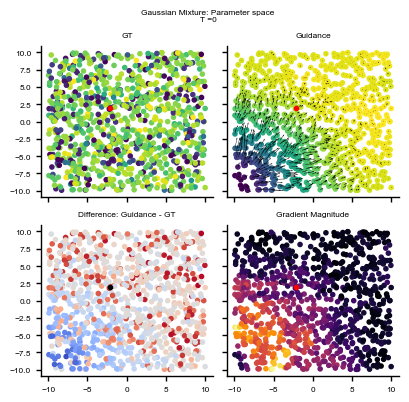

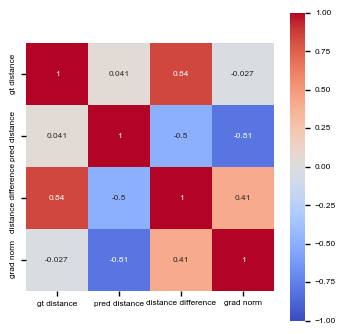

In [37]:
x, theta = load_misspecified_data("../data/gaussian_mixture_1000.pt")
dist_matrix = compute_distances(mmd_dist, x, x)

idx = 2
T = 0

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta[[idx]], x, guidance, T)
plot_guidance_analytics(x, x[idx], dist_matrix[idx], pred_dist.squeeze(), x_grad, f"Gaussian Mixture: Observation space\n{T =}")
plot_corr(dist_matrix[idx], pred_dist, x_grad)

pred_dist, (theta_grad, x_grad) = get_guidance_analytics(theta, x[[idx]], guidance, T)
plot_guidance_analytics(theta, theta[idx], dist_matrix[idx], pred_dist.squeeze(), theta_grad, f"Gaussian Mixture: Parameter space\n{T =}")
plot_corr(dist_matrix[idx], pred_dist, theta_grad)